Let's try doing the task 1 with multiple subjects 

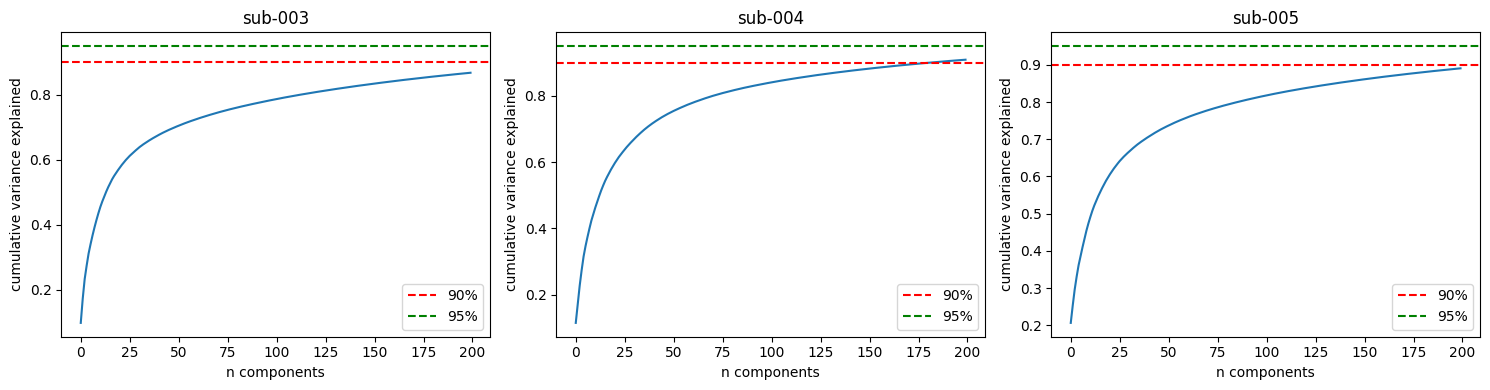

In [ ]:
# Let's check how many dimensions i will use with PCA after loading the data


import numpy as np
from scipy.io import loadmat
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

data_path = '/home/rbuu/psy3019/projet_final/data'
subjects = ['003', '004', '005']
n_tr = 10

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for i, sub in enumerate(subjects):
    # Load and average
    X = np.load(f'{data_path}/sub-{sub}/sub-{sub}_Resp_Training.npy', mmap_mode='r')
    X = X.T.reshape(480, n_tr, -1).mean(axis=1)  # (480, voxels)
    
    # Fit PCA
    pca = PCA(n_components=200)
    pca.fit(X)
    
    # Plot cumulative explained variance
    cumvar = np.cumsum(pca.explained_variance_ratio_)
    axes[i].plot(cumvar)
    axes[i].axhline(0.90, color='r', linestyle='--', label='90%')
    axes[i].axhline(0.95, color='g', linestyle='--', label='95%')
    axes[i].set_title(f'sub-{sub}')
    axes[i].set_xlabel('n components')
    axes[i].set_ylabel('cumulative variance explained')
    axes[i].legend()

plt.tight_layout()
plt.show()